In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


# US Consulate Sensor 2018 - 2022

In [3]:
import pandas as pd

input_file = "data/new/hcmc_weather_and_aqi.csv"  
df = pd.read_csv(input_file)
df.head()

,datetime,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2018-01-01 00:00:00,23.5,71,9.0,23,1009.7,0.0,6,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01 01:00:00,22.9,74,8.3,18,1009.5,0.0,10,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01 02:00:00,22.4,75,7.9,16,1009.0,0.0,16,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-01 03:00:00,22.0,75,8.6,15,1008.4,0.0,74,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01 04:00:00,21.9,75,8.9,14,1008.3,0.0,96,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

datetime                    0
temperature_2m              0
relative_humidity_2m        0
wind_speed_10m              0
wind_direction_10m          0
surface_pressure            0
precipitation               0
cloud_cover                 0
pm2_5                   40231
pm10                    40231
carbon_monoxide         40231
nitrogen_dioxide        40231
sulphur_dioxide         40231
ozone                   40231
dtype: int64

In [9]:
df=df.dropna()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30329 entries, 40231 to 70559
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              30329 non-null  str    
 1   temperature_2m        30329 non-null  float64
 2   relative_humidity_2m  30329 non-null  int64  
 3   wind_speed_10m        30329 non-null  float64
 4   wind_direction_10m    30329 non-null  int64  
 5   surface_pressure      30329 non-null  float64
 6   precipitation         30329 non-null  float64
 7   cloud_cover           30329 non-null  int64  
 8   pm2_5                 30329 non-null  float64
 9   pm10                  30329 non-null  float64
 10  carbon_monoxide       30329 non-null  float64
 11  nitrogen_dioxide      30329 non-null  float64
 12  sulphur_dioxide       30329 non-null  float64
 13  ozone                 30329 non-null  float64
dtypes: float64(10), int64(3), str(1)
memory usage: 3.8 MB


<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Eroz\AppData\Local\Temp\ipykernel_24356\3582723095.py:5: SyntaxWarning: invalid escape sequence '\C'
  input_file = "data\Clean For Model\Air_Quality_linear_ready2.csv"
C:\Users\Eroz\AppData\Local\Temp\ipykernel_24356\3582723095.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


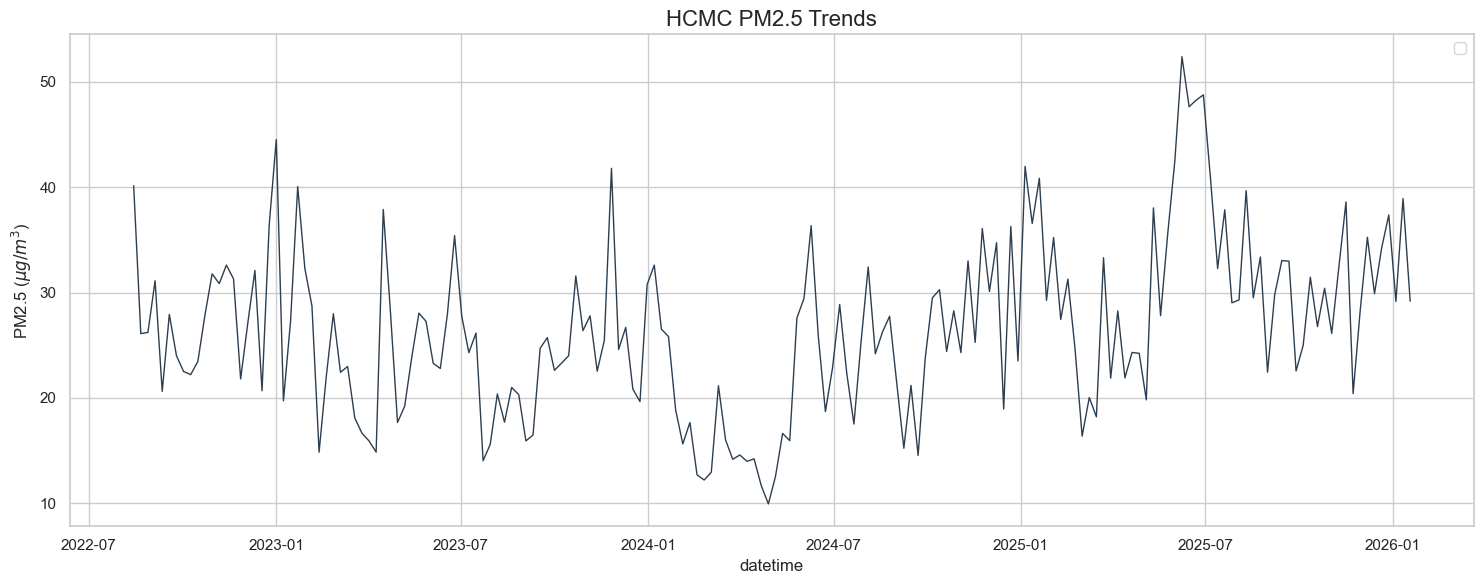

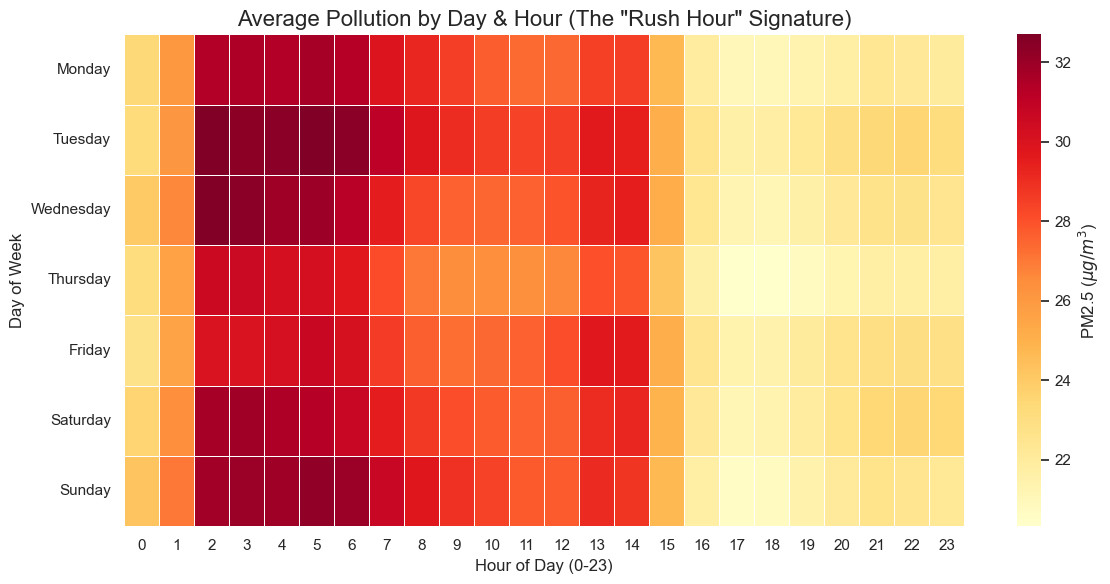

C:\Users\Eroz\AppData\Local\Temp\ipykernel_24356\3582723095.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)


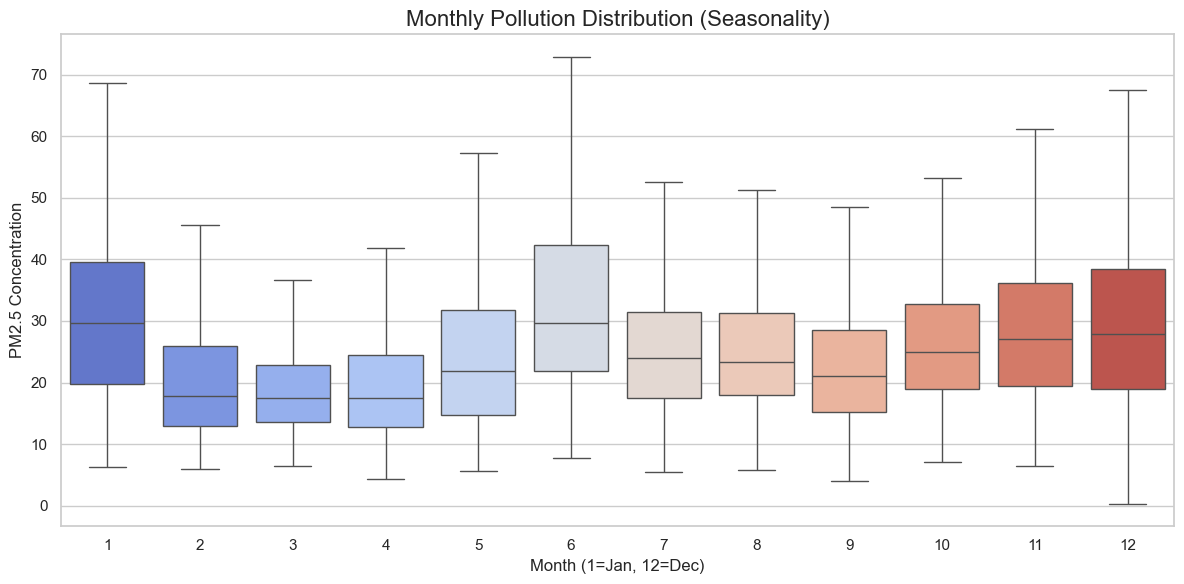

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_file = "data\Clean For Model\Air_Quality_linear_ready2.csv"

def plot(input_file):

    df = pd.read_csv(input_file)
    df['datetime'] = pd.to_datetime(df['datetime'])

    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['day_name'] = df['datetime'].dt.day_name()

    # Set the visual style
    sns.set_theme(style="whitegrid")

    # --- PLOT 1: THE 5-YEAR TIMELINE (The Big Picture) ---
    plt.figure(figsize=(15, 6))
    # Resample to Daily or Week or Month to make the plot readable (too much noise in hourly)
    daily_df = df.set_index('datetime').resample('W')['value'].mean().reset_index()

    sns.lineplot(data=daily_df, x='datetime', y='value', color='#2c3e50', linewidth=1)


    plt.title('HCMC PM2.5 Trends', fontsize=16)
    plt.ylabel('PM2.5 ($μg/m^3$)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: "RUSH HOUR" HEATMAP---
    # We pivot the data: Rows = Day of Week, Columns = Hour of Day
    pivot_table = df.pivot_table(index='day_name', columns='hour', values='value', aggfunc='mean')

    # Reorder days to start on Monday
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_table = pivot_table.reindex(days_order)

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, cmap="YlOrRd", linewidths=0.5, cbar_kws={'label': 'PM2.5 ($μg/m^3$)'})
    plt.title('Average Pollution by Day & Hour (The "Rush Hour" Signature)', fontsize=16)
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Day of Week')
    plt.tight_layout()
    plt.show()

    # --- PLOT 3: SEASONAL BOXPLOT (Rainy vs Dry Season) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)
    plt.title('Monthly Pollution Distribution (Seasonality)', fontsize=16)
    plt.xlabel('Month (1=Jan, 12=Dec)')
    plt.ylabel('PM2.5 Concentration')
    plt.tight_layout()
    plt.show()

plot(input_file)
